# Employee Salary Prediction Using Machine Learning

## Project Overview
This project predicts an employee's salary using **Linear Regression** based on:
- Age
- Gender
- Education Level
- Job Title
- Years of Experience

### Workflow
Data Loading → Data Cleaning → EDA → Feature Preparation → Encoding → Train/Test Split → Linear Regression → Evaluation → Prediction → Model Saving

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Salary_Data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (6704, 6)


## 2. Initial Data Inspection

In [2]:
print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB

Missing values:
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [3]:
print("Duplicate rows:", df.duplicated().sum())

print("\nNumerical summary:")
display(df.describe())

Duplicate rows: 4912

Numerical summary:


,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


## 3. Data Cleaning

The target variable `Salary` is required for supervised learning, so rows with missing salary are removed.

For missing feature values:
- Numerical columns → median
- Categorical columns → mode

The dataset also contains many exact duplicate rows. These are removed so the same record is not repeatedly used during model training.

In [4]:
df_clean = df.copy()

# Remove rows where the target is missing
df_clean = df_clean.dropna(subset=["Salary"])

# Fill numerical missing values
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Years of Experience"] = df_clean["Years of Experience"].fillna(
    df_clean["Years of Experience"].median()
)

# Fill categorical missing values
for col in ["Gender", "Education Level", "Job Title"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nShape before duplicate removal:", df_clean.shape)

df_clean = df_clean.drop_duplicates()

print("Shape after duplicate removal:", df_clean.shape)
print("Remaining duplicate rows:", df_clean.duplicated().sum())

Missing values after cleaning:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

Shape before duplicate removal: (6699, 6)
Shape after duplicate removal: (1788, 6)
Remaining duplicate rows: 0


## 4. Standardize Education Categories

In [5]:
df_clean["Education Level"] = df_clean["Education Level"].replace({
    "Bachelor's": "Bachelor's Degree",
    "Master's": "Master's Degree",
    "phD": "PhD"
})

print(df_clean["Education Level"].value_counts())

Education Level
Bachelor's Degree    769
Master's Degree      568
PhD                  341
High School          110
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

In [6]:
print("Gender distribution:")
print(df_clean["Gender"].value_counts())

print("\nTop 20 Job Titles:")
display(df_clean["Job Title"].value_counts().head(20))

print("\nUnique Job Titles:", df_clean["Job Title"].nunique())

Gender distribution:
Gender
Male      967
Female    814
Other       7
Name: count, dtype: int64

Top 20 Job Titles:


Job Title
Software Engineer Manager    127
Full Stack Engineer          122
Senior Software Engineer      96
Senior Project Engineer       95
Back end Developer            81
Data Scientist                80
Software Engineer             78
Front end Developer           71
Marketing Manager             55
Product Manager               53
Data Analyst                  51
Web Developer                 34
Financial Manager             28
Director of Marketing         27
Director of HR                27
Marketing Coordinator         26
Junior Sales Associate        25
Content Marketing Manager     24
Software Developer            22
Operations Manager            22
Name: count, dtype: int64


Unique Job Titles: 192


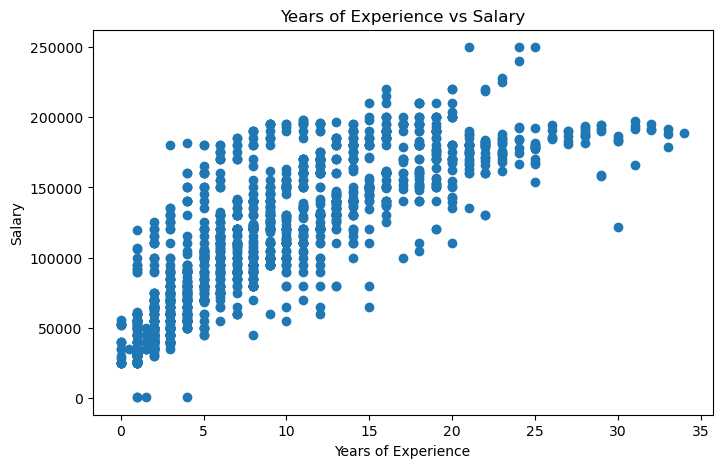

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["Years of Experience"], df_clean["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")
plt.show()

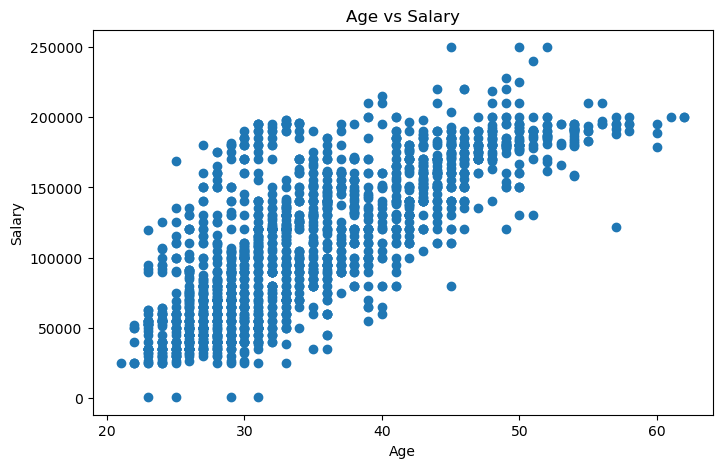

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["Age"], df_clean["Salary"])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

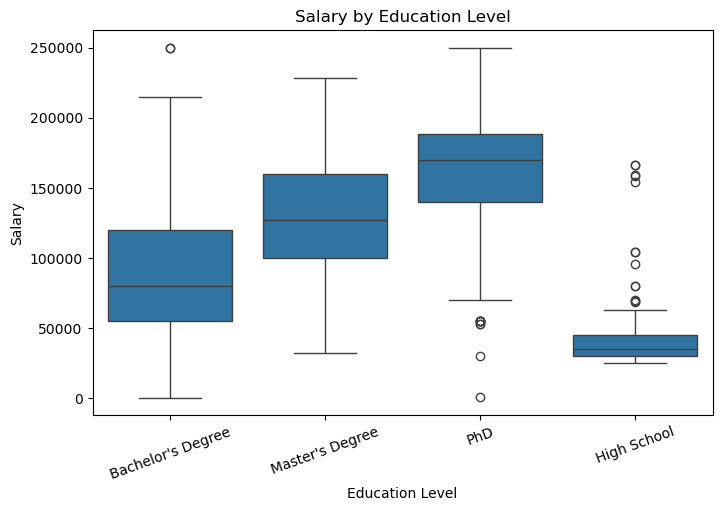

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Education Level", y="Salary", data=df_clean)
plt.xticks(rotation=20)
plt.title("Salary by Education Level")
plt.show()

### EDA Insights
- Salary generally increases as years of experience increase.
- Age also shows a generally positive relationship with salary.
- Salary distributions differ across education levels.
- `Job Title` has many categories, so it requires categorical encoding before model training.

## 6. Define Features and Target

In [10]:
X = df_clean.drop("Salary", axis=1)
y = df_clean["Salary"]

numeric_features = ["Age", "Years of Experience"]
categorical_features = ["Gender", "Education Level", "Job Title"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:", y.name)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features:
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience']

Target: Salary
X shape: (1788, 5)
y shape: (1788,)


## 7. Train/Test Split and Preprocessing

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1430, 5)
X_test: (358, 5)
y_train: (1430,)
y_test: (358,)


## 8. Train Linear Regression Model

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## 9. Model Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Model Performance
-----------------
MAE  : ₹14,860.65
RMSE : ₹20,466.92
R²   : 0.8468


### Metric Interpretation
- **MAE**: Average absolute difference between actual and predicted salary.
- **RMSE**: Penalizes larger prediction errors more strongly.
- **R²**: Proportion of salary variation explained by the model.

## 10. Actual vs Predicted Salary

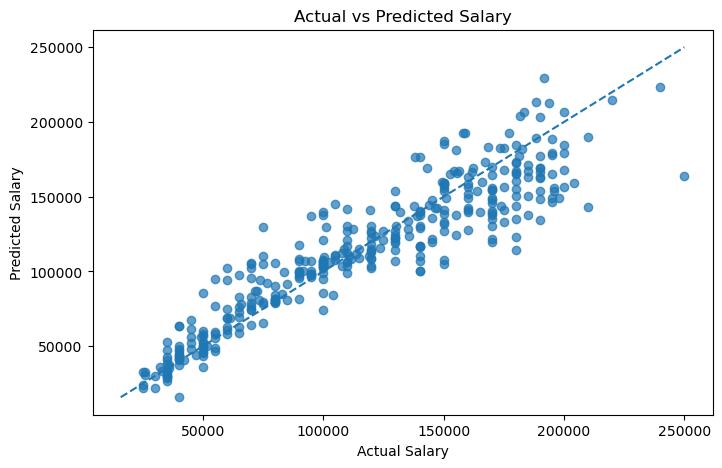

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)

# Reference line for perfect predictions
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

## 11. Single Employee Salary Prediction

In [15]:
new_employee = pd.DataFrame({
    "Age": [25],
    "Gender": ["Male"],
    "Education Level": ["Bachelor's Degree"],
    "Job Title": ["Data Analyst"],
    "Years of Experience": [2]
})

predicted_salary = linear_model.predict(new_employee)[0]

print(f"Predicted Salary: ₹{predicted_salary:,.2f}")

Predicted Salary: ₹106,210.47


## 12. Multiple Employee Predictions

In [16]:
employees = pd.DataFrame({
    "Age": [25, 30, 35, 40, 28],
    "Gender": ["Male", "Female", "Male", "Female", "Male"],
    "Education Level": [
        "Bachelor's Degree",
        "Master's Degree",
        "PhD",
        "Master's Degree",
        "Bachelor's Degree"
    ],
    "Job Title": [
        "Data Analyst",
        "Software Engineer",
        "Data Scientist",
        "Project Manager",
        "Business Analyst"
    ],
    "Years of Experience": [2, 5, 8, 12, 3]
})

employees["Predicted Salary"] = linear_model.predict(employees)

display(employees)

,Age,Gender,Education Level,Job Title,Years of Experience,Predicted Salary
0,25,Male,Bachelor's Degree,Data Analyst,2,106210.472389
1,30,Female,Master's Degree,Software Engineer,5,114416.458493
2,35,Male,PhD,Data Scientist,8,152308.331305
3,40,Female,Master's Degree,Project Manager,12,137927.599268
4,28,Male,Bachelor's Degree,Business Analyst,3,57764.563279


## 13. Save and Reload the Trained Model

In [17]:
import joblib

model_path = "salary_prediction_model.pkl"

joblib.dump(linear_model, model_path)
print(f"Model saved successfully: {model_path}")

Model saved successfully: salary_prediction_model.pkl


In [18]:
loaded_model = joblib.load(model_path)

test_prediction = loaded_model.predict(new_employee)[0]

print("Model loaded successfully!")
print(f"Reloaded model prediction: ₹{test_prediction:,.2f}")

Model loaded successfully!
Reloaded model prediction: ₹106,210.47


## 14. Final Project Summary

### Model
**Linear Regression**

### Features
- Age
- Gender
- Education Level
- Job Title
- Years of Experience

### Target
**Salary**

### Model Performance
The current cleaned dataset and train/test split produce an **R² score of approximately 0.85** with an MAE of approximately **₹14.9K**.

### Conclusion
The model demonstrates that employee characteristics such as experience, age, education, and job title can be used to estimate salary. The model is suitable as a portfolio-level regression project and can be extended later with additional features, more advanced models, hyperparameter tuning, or a web application.